# **ConvNeXt-Tiny Lightweight Fine-Tuning**

*Created and runned with Google Colab*

This code has to be executed AFTER the other notebook (numbered as 01), follow the numeration. \
**Dataset**: *Rare Neurological Diseases MRI - curated ver*, from [Kaggle](https://www.kaggle.com/datasets/ahsanneural/rare-neurological-diseases-mri-curated-edition)

> This dataset is derived from the *"Benchmark Diagnostic MRI and Medical Imaging Dataset"* published on Mendeley Data by *Haseeb Hassan, M. Usman Akram, Waqas Ahmad, and Sajid Gul Khawaja (2024)*, available at this link [Mendeley Data](https://data.mendeley.com/datasets/d73rs38yk6/1)

**Goal**: measure the second strategy — *Transfer Learning* via lightweight fine-tuning of
ConvNeXt-Tiny (last stage + classification head) — and compare its robustness under data
scarcity against the frozen ResNet-50 + SVM baseline of notebook 01.


## **1) Drive mount & Kaggle dataset's download**


In order to correctly configure the project, in your drive there must be the folder for the project, in my case is inside the folder I use for my University projects.
Plus, to download the dataset directly from Kaggle (to have the last version), it is required to copy an info from your Kaggle's account as follows:
- Go to [Kaggle' site](https://www.kaggle.com/) and log in it
- By intercat with your profile photo on the top-right, go to `Settings`
- Search for the section `API` and `Generate New Token`, it will open a pop up with some info:
  - **API TOKEN** (`KGAT_...`): This is your unique password. Copy it now, because Kaggle will never show it to you again

  - **Option 1** (`export KAGGLE_API_TOKEN=...`): It is used to save the token as a temporary environment variable in the terminal Linux/Mac.

  - **Option 2** (`mkdir -p ~/.kaggle && echo ...`): It is a terminal command that automatically creates the `~/.kaggle folder`, saves the token inside it in a file named `access_token`, and assigns the correct security permissions

  - **Final command** (kaggle competitions list): Example command to check if the token works.
- Copy the **API TOKEN** and return to Colab
- Open the menu on the left and intercat with the **key icon**
- Then add a **new secret**
  - **Name:** *KAGGLE_API_TOKEN*
  - **Value:** paste here the **API TOKEN**
- Finally, active the switch *"Notebook access"*



> If you don't want to use the key, you can **modify the code** when the key is required by pasting the API token in the else branch (section 2 of the following code)



By following those steps, you will be able to download the dataset directly from the Kaggle's site.


This cell is the only one that talks to the outside world. It does four things:
1. **Mounts Google Drive** so that data/features/models survive a runtime reset
2. **Reads the Kaggle token** from Colab Secrets (never hard-code it in a repo)
3. **Creates** the project folder tree on Drive
4. **Clones** the source repo and downloads the dataset if not already present
5. **Checks** if the dataset has already been downloaded. If so, it won't donwload it again

Everything downstream assumes the paths defined here.

In [ ]:
import os
from pathlib import Path
from google.colab import drive, userdata
import sys

# 1. Google Drive mount
# drive.mount() attaches the user's Drive under /content/drive
drive.mount('/content/drive')


# 2. Kaggle API configuration - AFTER adding the secret
# userdata.get() reads a secret stored in the Colab key panel
try:
    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
except Exception:
    # If you don't use Colab's Secret, you can directly paste your token here
    os.environ["KAGGLE_API_TOKEN"] = "KGAT_..."


# 3. Path configuration
# pathlib.Path is used instead of raw strings so that the "/" operator builds paths safely and the same code stays OS-independent
BASE_DIR = Path('/content/drive/MyDrive/University/rare-neuro-mri')
DATA_DIR = BASE_DIR / "data"                       # where to save dataset
MODEL_DIR = BASE_DIR / "convnext models"            # where to save the model
UTILS_DIR = BASE_DIR / "convnext utils"              # where to save useful files created during the analysis

# Create the base folder and the 'data' subfolder if they do not already exist
# parents=True  -> also create missing intermediate folders
# exist_ok=True -> do not raise if the folder is already there (idempotent cell)
for d in [DATA_DIR, MODEL_DIR, UTILS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 4. Clone GitHub repo & add src folder to the project
REPO_URL = "https://github.com/Rayoyo/rare-neuro-mri.git"
REPO_DIR = Path("/content/rare-neuro-mri")

if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}
print("Repo cloned!")

# repo added to importable moduls
if str(REPO_DIR) not in sys.path:
    sys.path.append(str(REPO_DIR))


# 5. Download verification and execution
# The "slug" is the <owner>/<dataset-name> identifier shown in the Kaggle URL
DATASET_SLUG = "ahsanneural/rare-neurological-diseases-mri-curated-edition"    #can be seen on Kaggle too when you want to download the file
 
# If the data folder is not empty, skip the download
if any(DATA_DIR.iterdir()):
    print(f" Dataset already present in: {DATA_DIR}")
    print("Folder contents:")
    for item in DATA_DIR.iterdir():
        print(f" - {item.name}")
else:
    print(f" Empty folder. Downloading the dataset '{DATASET_SLUG}'...")

    # Ensure that the Kaggle library is installed
    !pip install -q kaggle

    # Download and extract the data directly into the data folder on Drive
    !kaggle datasets download -d {DATASET_SLUG} -p "{DATA_DIR}" --unzip

    print(f"\n Download and extraction completed successfully!")
    print(f"The files are located in: {DATA_DIR}")


Mounted at /content/drive
Cloning into '/content/rare-neuro-mri'...
remote: Enumerating objects: 89, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 89 (delta 41), reused 61 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (89/89), 9.21 MiB | 2.89 MiB/s, done.
Resolving deltas: 100% (41/41), done.
Repo cloned!
 Dataset already present in: /content/drive/MyDrive/University/rare-neuro-mri/data
Folder contents:
 - rare_neuro_mri_curated


## **2) Install dependencies**

In this section are downloaded the requirements from the file in the github's repo.

- **Preferred path:** install the exact pinned versions from the repo's requirements.txt, so the notebook is reproducible across runtimes

- **Fallback path:** install only the minimum needed if the repo is unavailable \



> Note: `-q` keeps `pip` quiet. \
After installing packages that are already imported by Colab (e.g. numpy/torch), a runtime restart may be required




In [ ]:
# ---------------------------------------------------------
# Install dependencies
# ---------------------------------------------------------
# torchio and SimpleITK are now declared in requirements.txt (dataset.py imports them)

requirements_file = REPO_DIR / "requirements.txt"
if requirements_file.exists():
    !pip install -q -r {requirements_file}
else:
    !pip install -q scikit-learn matplotlib seaborn tqdm torchio SimpleITK


In [3]:
# Core imports: deep-learning backend, data handling, plotting, image I/O
import torch
import torch.nn as nn
import sys
import pandas as pd
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
from torch.utils.data import DataLoader

In [ ]:
# Numeric / metric helpers used below
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

In [ ]:
# ---------------------------------------------------------
# Reproducibility & Device Setup
# ---------------------------------------------------------

In [ ]:
'''The repo root was already appended to sys.path, but the modules live in
<repo>/src and are written as top-level modules (not a package), so src/ must
be on the path as well. insert(0, ...) puts it FIRST, so a local dataset.py
wins over any same-named installed package'''
src_dir_path = REPO_DIR / "src"
if str(src_dir_path) not in sys.path:
    sys.path.insert(0, str(src_dir_path))

'''What each imported helper does:
   verify_dataset_structure    -> checks <root>/<split>/<class>/ and that all splits share
                                   the same class list (label indices must match)
   build_dataloaders           -> train/val/test Datasets; return_train_eval=True also gives
                                   the training split WITHOUT augmentation
   build_fewshot_train_dataset -> training split with augmentation ON but aug_factor=1, so
                                   each physical image appears exactly once in a subset
   get_convnext_tiny_model     -> ImageNet ConvNeXt-Tiny, head replaced, backbone frozen
                                   except the last stage (lightweight fine-tuning)
   run_true_fewshot_finetuning -> re-initialises and re-fine-tunes the network on each subset
   evaluate_and_save_all       -> metrics + plots + few-shot study + artifact saving'''
from dataset import (set_dataset_root, build_dataloaders, build_fewshot_train_dataset,
                     visualize_augmentations, set_seed, verify_dataset_structure)
from transfer_learning import (get_convnext_tiny_model, train_one_epoch, validate_epoch,
                               extract_features_from_finetuned, count_trainable_parameters,
                               run_true_fewshot_finetuning)
from metrics import evaluate_and_save_all


In [6]:
# Select GPU if available, CPU if not
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## **3) Dataset structure & exploration**

This section is divided into three main codes:
1. **Data Structure Overview** \
Walk the dataset tree and print it as an indented outline, to verify that the folder layout matches what the `ImageFolder-style loader` expects: `<root>/<split>/<class_name>/<image>.jpg`

2. **Class Distribution** \
Counting images per (split, class) is the cheapest sanity check on a dataset: it reveals class imbalance, empty folders, or a broken download before any training time is wasted. \
Here it also confirms the counts declared on Kaggle
3. **Sample Grid Visualization** \
Qualitative inspection before modelling: one row per disease, n random training slices per row \
The goal is to see acquisition planes, contrast and preprocessing style, and to spot corrupted or off-domain images early

In [7]:
# ---------------------------------------------------------
# Data Structure Overview
# ---------------------------------------------------------

DATASET_ROOT = DATA_DIR / "rare_neuro_mri_curated"

# os.walk() yields (current_dir, subdirs, files) recursively, top-down
for root, dirs, files in os.walk(DATASET_ROOT):
  # Depth is inferred by counting the path separators left after stripping
  # the root prefix -> used to indent the printed tree
    level = root.replace(str(DATASET_ROOT), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    if level < 3 and files:
        for f in files[:3]:
            print(f'{subindent}{f} ...')
        if len(files) > 3:
            print(f'{subindent}... and {len(files)-3} more files')

rare_neuro_mri_curated/
  disease_summary.csv ...
  metadata.csv ...
  test/
    fukuyama_muscular_dystrophy/
      fukuyama_muscular_dystrophy_test_0000.jpg ...
      fukuyama_muscular_dystrophy_test_0001.jpg ...
      fukuyama_muscular_dystrophy_test_0002.jpg ...
      ... and 57 more files
    hallervorden_spatz_disease/
      hallervorden_spatz_disease_test_0000.jpg ...
      hallervorden_spatz_disease_test_0001.jpg ...
      hallervorden_spatz_disease_test_0002.jpg ...
      ... and 57 more files
    moyamoya_disease/
      moyamoya_disease_test_0000.jpg ...
      moyamoya_disease_test_0001.jpg ...
      moyamoya_disease_test_0002.jpg ...
      ... and 57 more files
    pachygyria_cerebellar_hypoplasia/
      pachygyria_cerebellar_hypoplasia_test_0000.jpg ...
      pachygyria_cerebellar_hypoplasia_test_0001.jpg ...
      pachygyria_cerebellar_hypoplasia_test_0002.jpg ...
      ... and 57 more files
    walker_warburg_syndrome/
      walker_warburg_syndrome_test_0000.jpg ...
      

In [ ]:
# ---------------------------------------------------------
# Split verification & Class Distribution
# ---------------------------------------------------------
'''Same invariant as notebook 01: the Kaggle archive already ships the 70/15/15 split by
class, no re-splitting needed, but every split must expose the SAME class folders
MRIDataset assigns labels via sorted(folder_names) independently per split, so a class
missing from one split would shift every subsequent label and the model would train against permuted targets
verify_dataset_structure() raises immediately if that happens'''

disease_classes, split_counts = verify_dataset_structure(DATASET_ROOT)

df_stats = pd.DataFrame(split_counts).fillna(0).astype(int)
print("\nDataset Statistics:")
print(df_stats)
print(f"Total images: {df_stats.sum().sum()}")
print(f"Canonical class order: {disease_classes}")



> ***Output comment:*** \
The dataset is perfectly balanced - 280 train / 60 val / 60 test for each of the 5 classes, 2000 images in total (70/15/15 split) \
Perfect balance is why plain accuracy is a fair metric in this case, and why macro-F1 and weighted-F1 come out almost identical later on


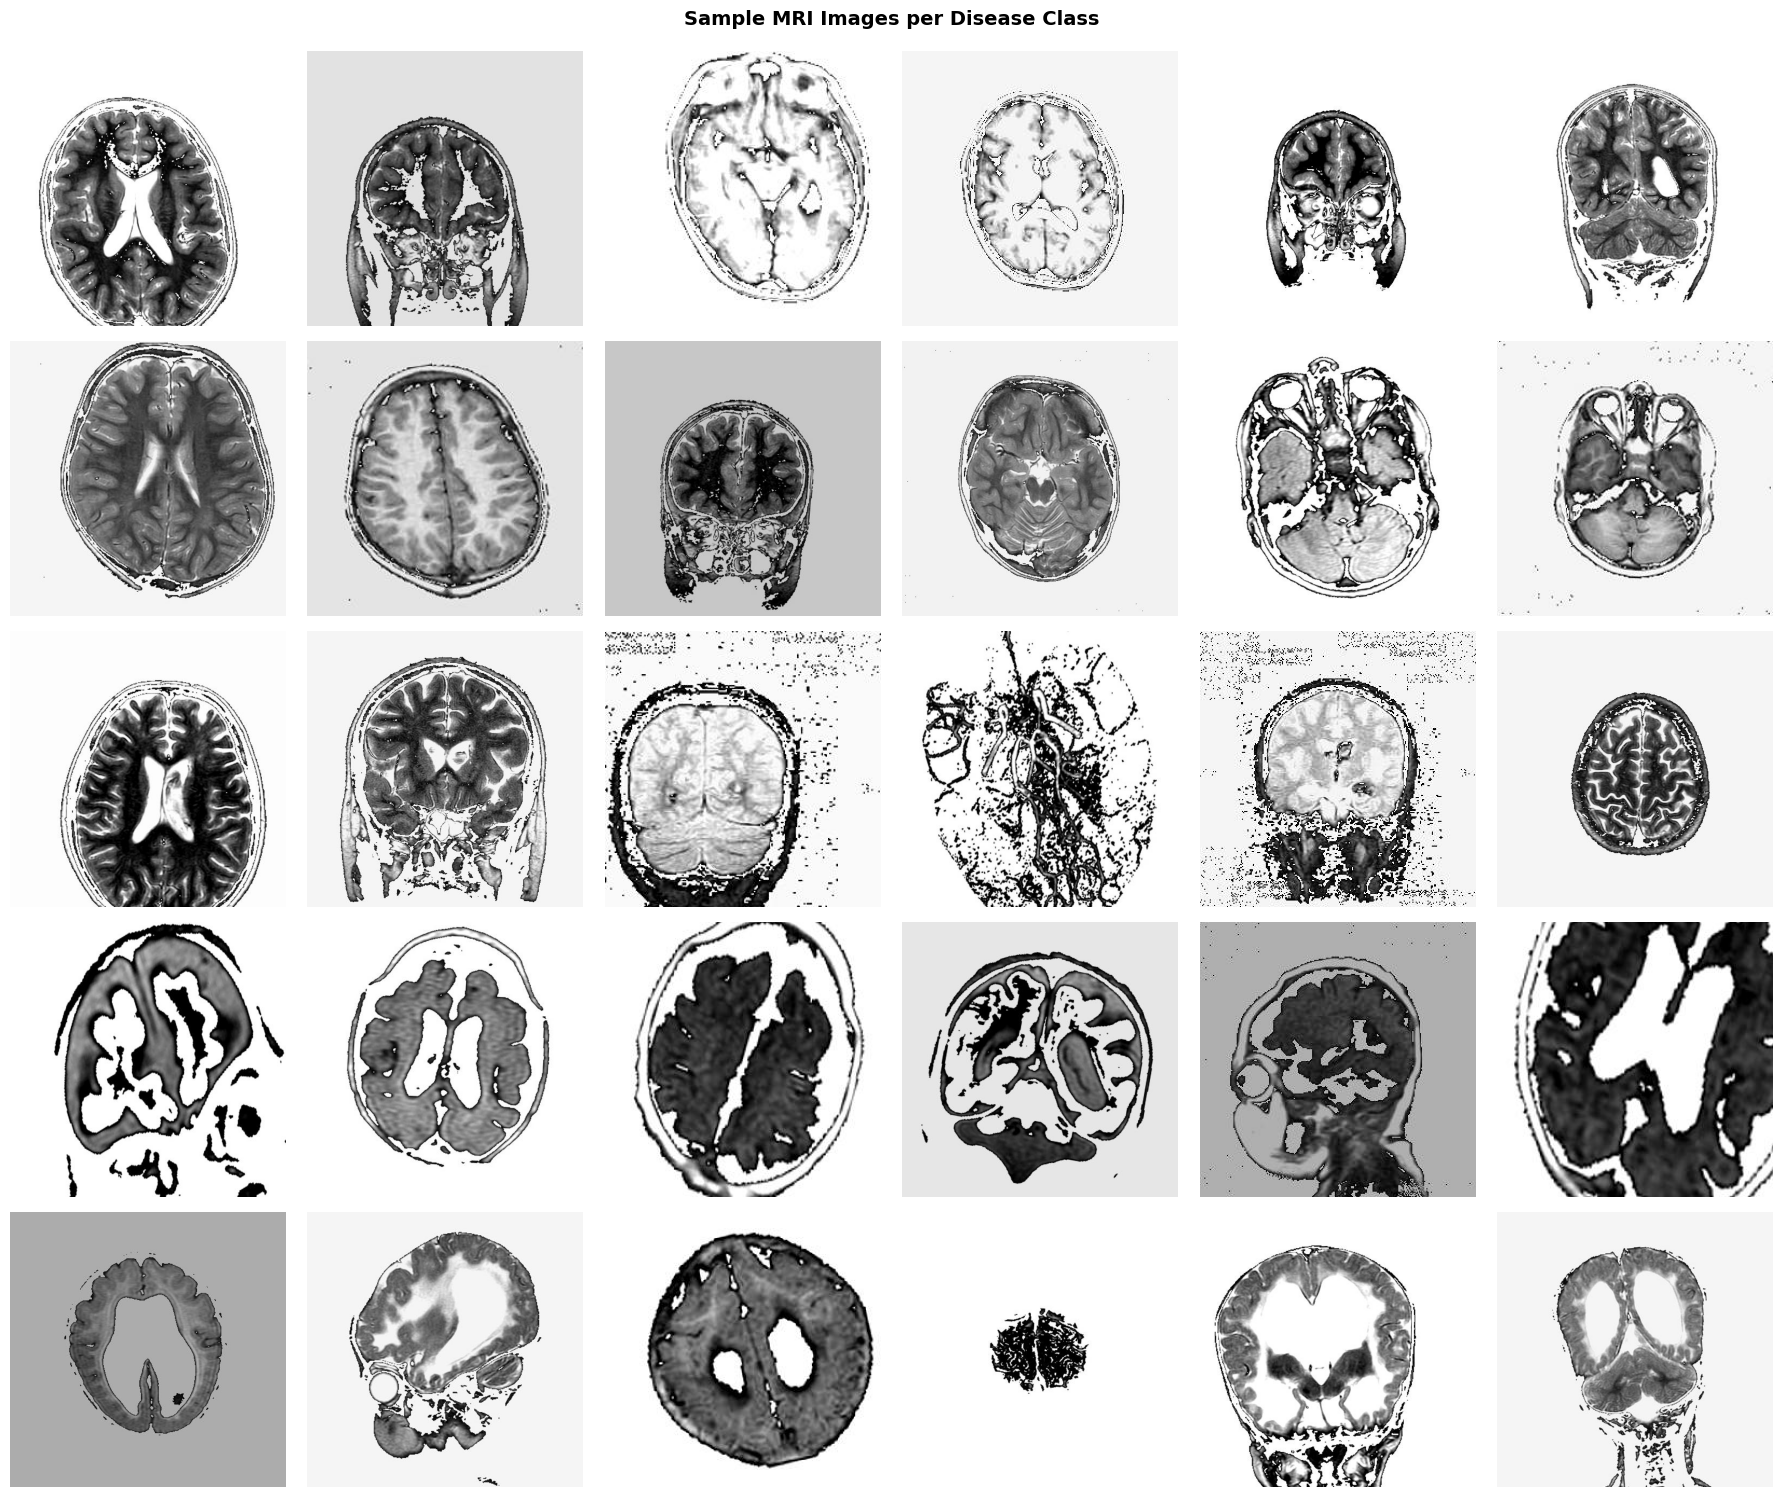

In [9]:
# ---------------------------------------------------------
# Sample Grid Visualization
# ---------------------------------------------------------

def show_samples(n_per_class=4):
  # One subplot row per class, one column per requested sample
    fig, axes = plt.subplots(len(disease_classes), n_per_class,
                             figsize=(n_per_class*3, len(disease_classes)*3))
    train_path = os.path.join(DATASET_ROOT, 'train')

    for i, cls in enumerate(disease_classes):
        cls_path = os.path.join(train_path, cls)
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        # random.sample() draws WITHOUT replacement, so no duplicated tiles
        # min(...) protects against classes with fewer images than requested
        sampled = random.sample(images, min(n_per_class, len(images)))
        for j, img_name in enumerate(sampled):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)
            # cmap='gray' only when the file is single-channel ('L' mode)
            # RGB files must be shown without a colormap
            axes[i, j].imshow(img, cmap='gray' if img.mode == 'L' else None)
            axes[i, j].axis('off')
            if j == 0:
                '''CAVEAT: axis('off') above hides the whole axis, including its ylabel -
                so this class name is NOT rendered in the figure
                Use axes[i, j].set_title(cls) or ax.text(...) instead if the row labels are needed'''
                axes[i, j].set_ylabel(cls, fontsize=10, fontweight='bold',
                                      rotation=0, ha='right', va='center')

    plt.suptitle('Sample MRI Images per Disease Class', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(UTILS_DIR / "sample_grid.png", dpi=150, bbox_inches='tight')
    plt.show()

show_samples(6)

> ### **Output comment:**  *Sample MRI Images per Disease Class*
>
> **What is plotted:**
>
> **What it shows**
>

## **4) Data transformation**

In this part are done some things:
- Set the global seed used in the notebook
- Initialization of the dataset in order to use the data augmentation only during the training
- Are shown some random samples of the transformation done
- The standard PyTorch data loaders is initialized

In [10]:
# Global seed on notebook & dataset root
'''set_seed() seeds Python's random, NumPy and PyTorch in one call, so the augmentations,
the train/val sampling and the SVM tie-breaking are repeatable
Any change to SEED changes every stochastic result in the notebook
'''
SEED = 33
set_seed(SEED)

set_dataset_root(DATASET_ROOT)

Global dataset root set to: /content/drive/MyDrive/University/rare-neuro-mri/data/rare_neuro_mri_curated


In [ ]:
# Dataset initialization (Data Augmentation active only on train)
'''Three flavours of the training split are needed here:

  train_ds       -> augmentation ON, aug_factor=2. Used for the actual fine-tuning
  train_eval_ds  -> augmentation OFF, aug_factor=1. Used for feature extraction and for any
                     measurement: fixed images, one vector each
  fewshot_ds     -> augmentation ON, aug_factor=1 (built later)
                     Needed so a few-shot subset of n indices contains n DISTINCT images; 
                     with aug_factor=2 the same image could be drawn twice and n_per_class would be a lie'''
train_ds, val_ds, test_ds, train_eval_ds = build_dataloaders(
    dataset_root=DATASET_ROOT,
    batch_size=32,
    img_size=224,
    aug_factor=2,
    seed=SEED,
    return_train_eval=True,
    classes=disease_classes
)

print(f"train (augmented, aug_factor=2): {len(train_ds)} samples "
      f"({train_ds.n_unique_samples} distinct images)")
print(f"train (clean, for extraction):   {len(train_eval_ds)} samples")
print(f"val: {len(val_ds)} | test: {len(test_ds)}")
print(f"class_to_idx: {train_eval_ds.class_to_idx}")


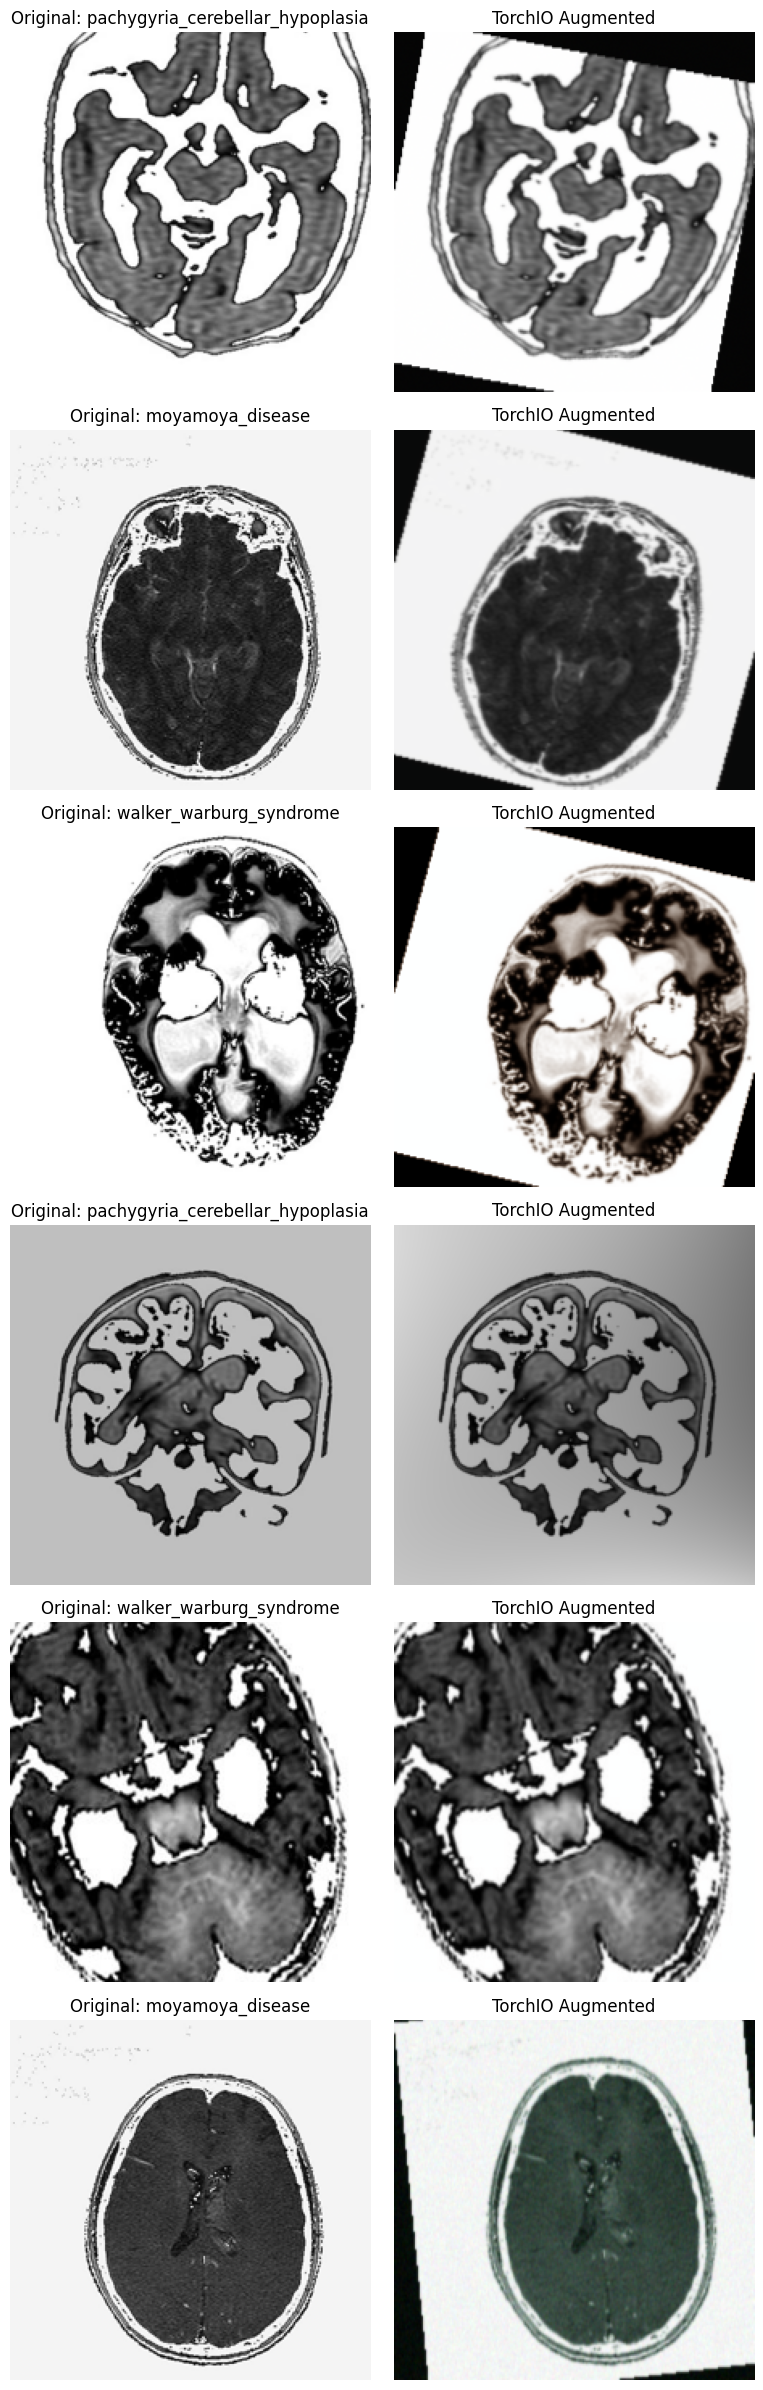

In [ ]:
# View some random examples to verify the quality of the transformations
''' original vs transformed pairs
Overly aggressive transforms (extreme rotation, intensity shifts that erase the lesion, flips that break left/right anatomy) 
silently destroy the signal the model is supposed to learn
Same seed as above -> same samples every run'''

visualize_augmentations(train_ds, num_samples=6, seed=SEED)

> ### **Output comment:** *Original vs. TorchIO-augmented samples*
>
> **What is plotted:**
>
> **Transforms visible in this run**

In [13]:
# Initialize the standard PyTorch DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
# the number of distinct training images per class is needed to build the few-shot subsets
N_PER_CLASS_FULL = train_ds.n_unique_samples // len(disease_classes)
print(f"Distinct training images per class (full regime): {N_PER_CLASS_FULL}")

## **Lightweight End-to-End Fine-Tuning**

Only the last ConvNeXt stage (`features[7]`) and the new classification head are trainable.
`freeze_backbone` now defaults to `True` in `get_convnext_tiny_model`: the previous default of
`False` contradicted the "lightweight fine-tuning" claim and would have quietly trained all
~28M parameters on 1400 images.


In [ ]:
# Model initialization with lightweight fine-tuning (only the last stage and the head unlocked)
model = get_convnext_tiny_model(
    num_classes=len(disease_classes),
    freeze_backbone=True,
    unfreeze_last_stage=True,
    device=DEVICE
)

trainable, total = count_trainable_parameters(model)
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# Training hyperparameters
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2


In [15]:
# Optimizer AdamW & Loss CrossEntropy
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [16]:
# End-to-End Training Loop with Checkpointing on the best Validation Loss

best_val_loss = float('inf')
best_model_path = MODEL_DIR / "convnext_tiny_best.pth"

print("Starting ConvNeXt-Tiny End-to-End Fine-Tuning...\n")

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, DEVICE)

    scheduler.step()

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS:02d}] | "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

    # Save the weights of the best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

print(f"\nTraining completed! Best model saved to: {best_model_path}")

Starting ConvNeXt-Tiny End-to-End Fine-Tuning...

Epoch [01/15] | Train Loss: 0.6325 - Train Acc: 0.8071 | Val Loss: 0.1285 - Val Acc: 0.9633
Epoch [02/15] | Train Loss: 0.1072 - Train Acc: 0.9821 | Val Loss: 0.0287 - Val Acc: 0.9967
Epoch [03/15] | Train Loss: 0.0507 - Train Acc: 0.9904 | Val Loss: 0.0212 - Val Acc: 0.9933
Epoch [04/15] | Train Loss: 0.0370 - Train Acc: 0.9932 | Val Loss: 0.0171 - Val Acc: 0.9933
Epoch [05/15] | Train Loss: 0.0283 - Train Acc: 0.9943 | Val Loss: 0.0106 - Val Acc: 0.9967
Epoch [06/15] | Train Loss: 0.0185 - Train Acc: 0.9986 | Val Loss: 0.0057 - Val Acc: 0.9967
Epoch [07/15] | Train Loss: 0.0152 - Train Acc: 0.9982 | Val Loss: 0.0076 - Val Acc: 0.9967
Epoch [08/15] | Train Loss: 0.0153 - Train Acc: 0.9982 | Val Loss: 0.0132 - Val Acc: 0.9933
Epoch [09/15] | Train Loss: 0.0130 - Train Acc: 0.9982 | Val Loss: 0.0018 - Val Acc: 1.0000
Epoch [10/15] | Train Loss: 0.0109 - Train Acc: 0.9989 | Val Loss: 0.0021 - Val Acc: 1.0000
Epoch [11/15] | Train Loss: 0.

### **Test set evaluation and feature extraction**

Features are extracted from `train_eval_ds` (no augmentation, no duplication): the fine-tuned
768-D embeddings are meant to be a fixed description of each image.


In [ ]:
# Load the weights of the best model obtained during validation
model.load_state_dict(torch.load(best_model_path))

# Obtain predictions and true labels on the pristine test set
test_loss, test_acc, y_test, test_preds = validate_epoch(model, test_loader, criterion, DEVICE)
print(f"\nConvNeXt-Tiny Final Test Accuracy: {test_acc:.4f} (Test Loss: {test_loss:.4f})")

from sklearn.metrics import f1_score
test_macro_f1 = f1_score(y_test, test_preds, average='macro')
print(f"ConvNeXt-Tiny Final Test Macro-F1: {test_macro_f1:.4f}")

# Fine-tuned 768-D features, from the CLEAN training split
X_train_feats, y_train_labels = extract_features_from_finetuned(model, train_eval_ds, device=DEVICE)
X_test_feats, _ = extract_features_from_finetuned(model, test_ds, device=DEVICE)
print(f"\nFine-tuned features: train {X_train_feats.shape} | test {X_test_feats.shape}")


## **Few-shot robustness — the honest protocol**

The previous version of this notebook reused the same routine as notebook 01: extract features
from the fine-tuned model, then retrain a small SVM on progressively smaller subsets. That is
valid for a **frozen** backbone, where the features never saw the labels, but it is **not** valid
here. These features come from a network that was already fine-tuned on the *entire* training
set, so the full-data supervision leaks into every "few-shot" point. That is exactly why the old
curve read ~0.996 accuracy at 10 examples per class: it was never measuring a low-data regime.

The protocol below is the real one. For each subset size, and for each repetition:

1. draw a **class-balanced subset** of distinct training images;
2. **re-initialise ConvNeXt-Tiny from ImageNet weights** — nothing carries over from the full run;
3. fine-tune on that subset only;
4. evaluate on the untouched test set.

**Cost.** This is genuinely expensive: `len(fewshot_sizes) × n_runs` complete fine-tuning runs.
With the defaults below (5 sizes × 3 runs × 8 epochs) expect roughly 30–60 minutes on a Colab
T4. Lower `N_FEWSHOT_RUNS` or `FEWSHOT_EPOCHS` if the runtime is a problem — and if you do, say
so in the report, because fewer repetitions means wider error bars.


In [ ]:
# ---------------------------------------------------------
# TRUE few-shot: re-fine-tune from ImageNet on each subset
# ---------------------------------------------------------

FEWSHOT_SIZES = (10, 25, 50, 100, 200)
N_FEWSHOT_RUNS = 3      # repetitions per size -> the error bars
FEWSHOT_EPOCHS = 8      # epochs per run (subsets are small, they converge fast)

# Augmentation ON (it is training) but aug_factor=1, so a subset of n indices
# really contains n distinct images
fewshot_train_ds = build_fewshot_train_dataset(
    DATASET_ROOT, img_size=224, classes=disease_classes
)
print(f"Few-shot pool: {len(fewshot_train_ds)} distinct training images "
      f"({N_PER_CLASS_FULL} per class)\n")

fewshot_df = run_true_fewshot_finetuning(
    train_dataset=fewshot_train_ds,
    test_dataset=test_ds,
    class_names=disease_classes,
    device=DEVICE,
    fewshot_sizes=FEWSHOT_SIZES,
    n_runs=N_FEWSHOT_RUNS,
    epochs=FEWSHOT_EPOCHS,
    batch_size=32,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    freeze_backbone=True,
    unfreeze_last_stage=True,
    full_acc=test_acc,
    full_f1=test_macro_f1,
    n_full_per_class=N_PER_CLASS_FULL,
    seed=SEED
)

print("\nFew-shot results (true re-fine-tuning):")
print(fewshot_df.to_string(index=False))


## **Metrics evaluation and artifact saving**

In [ ]:
# Artifacts to save for ConvNeXt
'''class_names is what turns an integer prediction into a disease name. It is passed here and
evaluate_and_save_all() also injects it defensively, raising if the two disagree.'''
artifacts = {
    'model_architecture': 'convnext_tiny',
    'class_names': disease_classes,
    'class_to_idx': train_eval_ds.class_to_idx,
    'img_size': 224,
    'freeze_backbone': True,
    'unfreeze_last_stage': True,
    'num_epochs': NUM_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'best_val_loss': float(best_val_loss),
    'calibrated_probabilities': False,  # softmax scores, not Platt-calibrated
}

# The few-shot curve is passed in precomputed: for a fine-tuned backbone the
# SVM-on-features shortcut is not a valid few-shot measurement
evaluate_and_save_all(
    y_true=y_test,
    y_pred=test_preds,
    class_names=disease_classes,
    utils_dir=UTILS_DIR,
    model_dir=MODEL_DIR,
    model_name="convnext_tiny_finetuned",
    fewshot_df=fewshot_df,
    fewshot_protocol=(f"ConvNeXt-Tiny re-initialised from ImageNet and re-fine-tuned on each "
                      f"subset ({N_FEWSHOT_RUNS} runs x {FEWSHOT_EPOCHS} epochs)"),
    artifacts_to_save=artifacts,
    torch_model_to_save=model,
    seed=SEED
)


> ### **Output comments** — *fill in after the new run*
>
> - **Confusion matrix / per-class metrics:** which classes are perfect, where the residual
>   errors sit, whether any confusion is clinically plausible.
> - **Few-shot curve — the interesting comparison.** Put this curve next to the ResNet-50 + SVM
>   one from notebook 01 and compare the *shapes*, not just the endpoints. The question the
>   project asks is which strategy degrades more gracefully as data becomes scarce, and only now
>   are the two curves measuring comparable things.
> - **A caveat worth stating explicitly in the report:** both models score very high on this
>   dataset even in the low-data regime. The five classes are visually distinctive and the slices
>   are heavily preprocessed, so a ceiling effect is likely and small differences between the two
>   approaches should not be over-interpreted.
